<a href="https://colab.research.google.com/github/arunabhachanda/predictive-maintenance-ml-dl/blob/main/Predictive_Maintenance_Phase1_AI4I2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


#**Phase 1 - Machine Failure Classification (AI4I 2020 Dataset)**

##Objective
Predict whether an industrial milling machine will fail, and if so, identify the type of failure —
enabling factories to shift from reactive to proactive maintenance.

##Dataset
- Source: AI4I 2020 Predictive Maintenance Dataset (UCI Machine Learning Repository)
- 10,000 rows × 14 columns — real industrial sensor readings from a milling machine
- Features: Air temperature, Process temperature, Rotational speed, Torque, Tool wear, Machine type
- Target: Machine failure (binary) + Failure type (TWF, HDF, PWF, OSF, RNF)

##Key EDA Findings
- Severe class imbalance: only 3.39% failures (339/10,000) → SMOTE required
- Low quality machines (Type L) had highest failure rate (~3.9%)
- HDF was the most common failure type (115 cases), RNF the rarest (19 cases)
- Air temp & Process temp highly correlated (0.88) — multicollinearity detected
- Rotational speed & Torque strongly negatively correlated (-0.88) — multicollinearity detected

##Feature Engineering
3 domain-driven features engineered from physics of rotating machinery:
- **Temp_Difference** = Process temp - Air temp → captures thermal stress beyond environment
- **Power** = Torque × Rotational speed → captures true mechanical load on machine
- **Torque_per_Wear** = Torque / (Tool wear + 1) → captures stress relative to tool age
→ Temp_Difference and Power emerged as the TOP 2 most important features in the final model

##Phase 1a — Binary Classification (Will it fail?)
- SMOTE applied on training data only to balance classes (7,729 vs 7,729)
- Three models trained: Random Forest, XGBoost, LightGBM
- LightGBM best across all metrics → hyperparameter tuned using RandomizedSearchCV (50 iterations, 5-fold CV)

| Model | F1 Score | Precision | Recall | ROC-AUC |
|-------|----------|-----------|--------|---------|
| Random Forest | 0.60 | 0.49 | 0.78 | 0.9658 |
| XGBoost | 0.67 | 0.57 | 0.81 | 0.9641 |
| LightGBM (default) | 0.71 | 0.62 | 0.84 | 0.9778 |
| **LightGBM (tuned)** | **0.79** | **0.79** | **0.79** | **0.9604** |

**Final model catches 54 out of 68 real failures in test set (79.4% recall)**

##Phase 1b — Multi-Class Classification (What type of failure?)
- Cascaded classifier — runs only on machines already flagged as failures by Phase 1a
- 330 failure rows, 4 classes (HDF/PWF/OSF/TWF), 9 unknowns dropped
- No SMOTE needed — classes relatively balanced
- Same tuned LightGBM architecture applied

| Failure Type | F1 Score | Support |
|-------------|----------|---------|
| HDF (Heat Dissipation) | 1.00 | 23 |
| PWF (Power Failure) | 0.97 | 18 |
| OSF (Overstrain) | 0.94 | 16 |
| TWF (Tool Wear) | 0.82 | 9 |
| **Overall** | **0.95** | **66** |

##Production Architecture
```
All machines → [Phase 1a: Will it fail?] → No  → Continue monitoring
                                         → Yes → [Phase 1b: What type of failure?]
                                                  → Schedule targeted maintenance
```

##Key Takeaways
- Engineered features outperformed raw sensor readings — domain knowledge drives better ML
- Recall prioritised over Precision — missing a real failure costs more than a false alarm
- Cascaded classifier mirrors real production ML system design at companies like Amazon and Siemens
- Phase 2 extends this by predicting *when* the machine will fail (Remaining Useful Life using LSTM/GRU)

##**Phase 1A**

In [2]:
# Loading AI4I 2020 Predictive Maintenance Dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Quick first look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


##**EDA**

In [3]:
print("=== Basic Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
df.describe()

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


##EDA - Observations (1)

- **Shape:** 10,000 rows × 14 columns
- **Missing Values:** None — dataset is completely clean, no imputation required
- **Data Types:** Sensor readings as float64, binary failure flags as int64, Type & Product ID as object
- **Severe Class Imbalance:** Only 3.39% failures (339/10,000) — SMOTE will be required to prevent the model from predicting "no failure" every time
- **Sensor Ranges:**
  - Air Temperature: 295–304K
  - Process Temperature: 305–313K
  - Rotational Speed: 1,168–2,886 rpm
  - Torque: 3.8–76.6 Nm
  - Tool Wear: 0–253 minutes
- **Next Step:** Visualising class imbalance, failure rates by machine type, and feature distributions

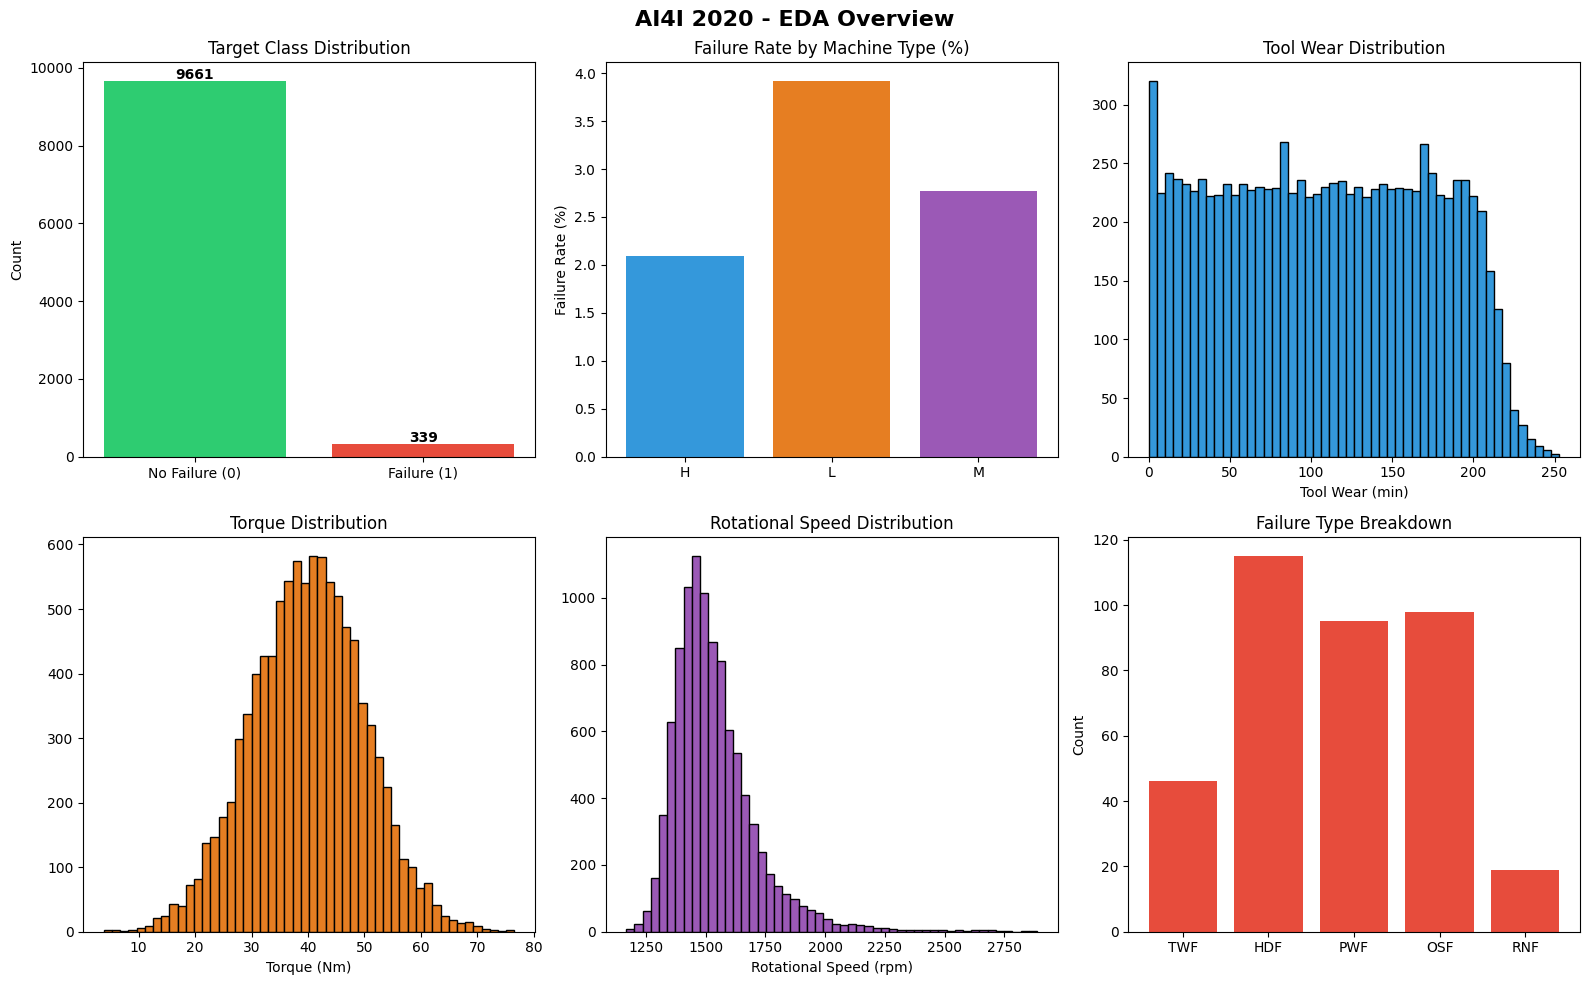

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('AI4I 2020 - EDA Overview', fontsize=16, fontweight='bold')

# 1. Class imbalance
axes[0, 0].bar(['No Failure (0)', 'Failure (1)'],
               df['Machine failure'].value_counts().values,
               color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Target Class Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(df['Machine failure'].value_counts().values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Failure by machine type
type_failure = df.groupby('Type')['Machine failure'].mean() * 100
axes[0, 1].bar(type_failure.index, type_failure.values, color=['#3498db', '#e67e22', '#9b59b6'])
axes[0, 1].set_title('Failure Rate by Machine Type (%)')
axes[0, 1].set_ylabel('Failure Rate (%)')

# 3. Tool wear distribution
axes[0, 2].hist(df['Tool wear [min]'], bins=50, color='#3498db', edgecolor='black')
axes[0, 2].set_title('Tool Wear Distribution')
axes[0, 2].set_xlabel('Tool Wear (min)')

# 4. Torque distribution
axes[1, 0].hist(df['Torque [Nm]'], bins=50, color='#e67e22', edgecolor='black')
axes[1, 0].set_title('Torque Distribution')
axes[1, 0].set_xlabel('Torque (Nm)')

# 5. Rotational speed distribution
axes[1, 1].hist(df['Rotational speed [rpm]'], bins=50, color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Rotational Speed Distribution')
axes[1, 1].set_xlabel('Rotational Speed (rpm)')

# 6. Failure type breakdown
failure_types = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()
axes[1, 2].bar(failure_types.index, failure_types.values, color='#e74c3c')
axes[1, 2].set_title('Failure Type Breakdown')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

##EDA - Observations (2)

- **Class Imbalance confirmed:** 9,661 no-failure vs 339 failure — SMOTE required
- **Machine Type matters:** L (low quality) has highest failure rate (~ 3.9%), H (high quality) lowest (~ 2.1%) — Type is a useful feature
- **Tool Wear:** Uniform distribution 0–200 mins, drops after 200 — machines likely serviced around this threshold
- **Torque:** Normal distribution ~40 Nm — no transformation needed
- **Rotational Speed:** Right-skewed, most at ~1500 rpm — high speeds likely correlate with failure
- **Most common failure:** HDF (Heat Dissipation, ~115 cases)
- **Rarest failure:** RNF (Random, ~19 cases)
- **Feature engineering insight:** High torque + high speed + high tool wear = high failure risk — will engineer combined features

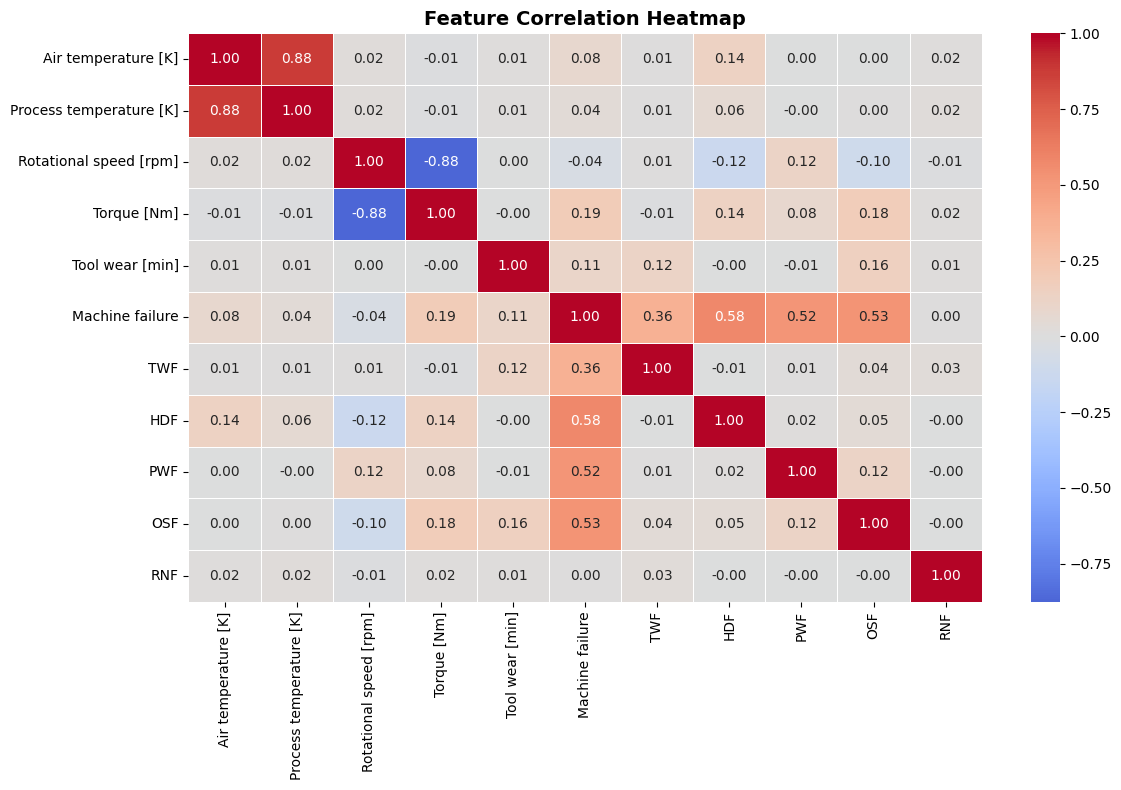

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['Product ID', 'UDI', 'Type']).corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##EDA - Correlation Heatmap Observations

- **Strongest predictors of Machine Failure:** HDF (0.58) > OSF (0.53) > PWF (0.52) > TWF (0.36) > Torque (0.19) > Tool wear (0.11)
- **RNF has zero correlation** — purely random, no learnable pattern
- **Multicollinearity 1:** Air temp & Process temp highly correlated (0.88) → engineer Temperature Difference feature
- **Multicollinearity 2:** Rotational speed & Torque strongly negatively correlated (-0.88) → engineer Power feature
- **Feature Engineering Plan:**
  - Temperature Difference = Process temp - Air temp
  - Power = Torque × Rotational speed
  - Torque per Wear = Torque / (Tool wear + 1)

##**Preprocessing & Feature Engineering**

In [6]:
# Drop identifier columns
df = df.drop(columns=['UDI', 'Product ID'])

# Encode Type column (L=0, M=1, H=2)
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
print("Type encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Feature Engineering
df['Temp_Difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['Torque_per_Wear'] = df['Torque [Nm]'] / (df['Tool wear [min]'] + 1)

print("\nNew shape after feature engineering:", df.shape)
print("\nNew features added:")
print(df[['Temp_Difference', 'Power', 'Torque_per_Wear']].describe())

Type encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

New shape after feature engineering: (10000, 15)

New features added:
       Temp_Difference         Power  Torque_per_Wear
count     10000.000000  10000.000000     10000.000000
mean         10.000630  59967.147040         1.324723
std           1.001094  10193.093881         4.735015
min           7.600000  10966.800000         0.026168
25%           9.300000  53105.400000         0.239975
50%           9.800000  59883.900000         0.371277
75%          11.000000  66873.750000         0.735153
max          12.100000  99980.400000        68.500000


##Summary

- Dropped UDI and Product ID (identifiers, zero predictive value)
- Label encoded Type: H=0, L=1, M=2
- Engineered 3 new features:
  - **Temp_Difference:** Process temp - Air temp (mean ~10K) — captures thermal stress
  - **Power:** Torque × Rotational speed (mean ~60K) — physical energy load on machine
  - **Torque_per_Wear:** Torque / (Tool wear + 1) — stress per unit of tool age (right skewed, max 68.5)
- New shape: 10,000 × 15

##**Preparing Features & Target, Applying SMOTE**

In [8]:
# Define features and target
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine failure']

print("Features:", X.columns.tolist())
print("Feature matrix shape:", X.shape)
print("\nClass distribution before SMOTE:")
print(y.value_counts())

# Train-test split BEFORE SMOTE (very important — never apply SMOTE before splitting)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nClass distribution in training set before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass distribution in training set after SMOTE:")
print(y_train_sm.value_counts())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("\nData ready for modelling!")

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Difference', 'Power', 'Torque_per_Wear']
Feature matrix shape: (10000, 9)

Class distribution before SMOTE:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Train size: (8000, 9)
Test size: (2000, 9)

Class distribution in training set before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Class distribution in training set after SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64

Data ready for modelling!


##Summary

- Features: 9 (original sensors + engineered features)
- Target: Machine failure (binary — 0/1)
- Train/Test split: 80/20 with stratification
- SMOTE applied ONLY on training data (never on test — prevents data leakage)
- Training set after SMOTE: 7,729 vs 7,729 — perfectly balanced
- Test set: 2,000 rows with original real-world distribution
- Features scaled using StandardScaler

##**Model Building**

##Classification Metrics - Quick Reference

**Accuracy** — % of total predictions that are correct. Misleading for imbalanced datasets
(e.g. predicting "no failure" every time gives 96.6% accuracy but catches zero failures)

**Precision** — Of all the times the model predicted "Failure", how many were actually failures?
→ High precision = fewer false alarms
Formula: TP / (TP + FP)

**Recall (Sensitivity)** — Of all actual failures, how many did the model correctly catch?
→ High recall = fewer missed failures
Formula: TP / (TP + FN)

**F1 Score** — Harmonic mean of Precision and Recall. Best single metric when both false
alarms and missed failures matter. Preferred over accuracy for imbalanced datasets.
Formula: 2 × (Precision × Recall) / (Precision + Recall)

**ROC-AUC** — Measures the model's overall ability to distinguish between classes across
all decision thresholds. Score of 1.0 = perfect, 0.5 = random guessing.

Imagine the model gives every machine a "failure risk score" between 0 and 1.
ROC-AUC measures how well the model separates the "will fail" machines from the "won't fail" machines
across every possible threshold.

Simple analogy: If you randomly picked one machine that failed and one that didn't,
ROC-AUC is the probability that the model correctly gave the failed machine a higher risk score.

- Score of 1.0 = model perfectly separates failures from non-failures every single time
- Score of 0.5 = model is no better than random guessing (coin flip)
- Score of 0.97 (ours) = 97% of the time, the model correctly ranks a real failure
  higher than a non-failure — very strong result

**The trade-off:**
- Optimise for Recall → catch more real failures, but more false alarms
- Optimise for Precision → fewer false alarms, but miss more real failures
- F1 Score → balances both

**In predictive maintenance: Recall is prioritised** — a missed failure (unexpected
machine breakdown) is far costlier than a false alarm (unnecessary maintenance check)

**Confusion Matrix:**
|  | Predicted No Failure | Predicted Failure |
|--|---------------------|------------------|
| **Actual No Failure** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual Failure** | False Negative (FN) ❌ | True Positive (TP) ✅ |

In [9]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# Train and evaluate all models
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_sm)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results[name] = {
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

# Summary comparison table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df.round(4))


  Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.49      0.78      0.60        68

    accuracy                           0.96      2000
   macro avg       0.74      0.88      0.79      2000
weighted avg       0.98      0.96      0.97      2000


  XGBoost
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.57      0.81      0.67        68

    accuracy                           0.97      2000
   macro avg       0.78      0.89      0.83      2000
weighted avg       0.98      0.97      0.97      2000


  LightGBM
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.62      0.84      0.71        68

    accuracy                           0.98      2000
   macro avg       0.81      0.91      0.85      2000
weighted avg       0.98      0.98 

##Results

| Model | F1 Score | Precision | Recall | ROC-AUC |
|-------|----------|-----------|--------|---------|
| Random Forest | 0.60 | 0.49 | 0.78 | 0.9658 |
| XGBoost | 0.67 | 0.57 | 0.81 | 0.9641 |
| **LightGBM** | **0.71** | **0.62** | **0.84** | **0.9778** |

- **Best model: LightGBM** across all metrics
- Recall prioritised over Precision — missing a real failure (false negative) is costlier than a false alarm in industrial maintenance
- LightGBM catches 84% of real failures before they happen
- ROC-AUC of 0.978 shows near-perfect class discrimination
- Next step: Hyperparameter tuning on LightGBM to further improve F1 and Recall

##**Hyperparameter tuning**

In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_tuned = LGBMClassifier(random_state=42, verbose=-1)

search = RandomizedSearchCV(
    lgbm_tuned,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_scaled, y_train_sm)

print("Best Parameters:", search.best_params_)
print("Best CV F1 Score:", round(search.best_score_, 4))

# Evaluate tuned model on test set
y_pred_tuned = search.best_estimator_.predict(X_test_scaled)
y_prob_tuned = search.best_estimator_.predict_proba(X_test_scaled)[:, 1]

print("\n=== Tuned LightGBM Results ===")
print(classification_report(y_pred_tuned, y_test, target_names=['No Failure', 'Failure']))
print("F1 Score:", round(f1_score(y_test, y_pred_tuned), 4))
print("Recall:", round(recall_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV F1 Score: 0.9943

=== Tuned LightGBM Results ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.79      0.79      0.79        68

    accuracy                           0.99      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000

F1 Score: 0.7941
Recall: 0.7941
Precision: 0.7941
ROC-AUC: 0.9604


##Hyperparameter Tuning Results

**Best Parameters:** subsample=0.8, num_leaves=20, n_estimators=500,
min_child_samples=10, max_depth=5, learning_rate=0.2, colsample_bytree=0.8

| Metric | Default LightGBM | Tuned LightGBM |
|--------|-----------------|----------------|
| F1 Score | 0.71 | **0.79** |
| Precision | 0.62 | **0.79** |
| Recall | 0.84 | 0.79 |
| ROC-AUC | 0.978 | 0.960 |

- Tuning improved F1 (+0.08) and Precision (+0.17) at slight cost to Recall (-0.05)
- Classic Precision-Recall trade-off — tuned model raises fewer but more confident alarms
- Model selection depends on business priority: catch every failure (default) vs fewer false alarms (tuned)
- CV F1 of 0.9943 vs test F1 of 0.79 gap is expected — CV on balanced SMOTE data, test on real distribution

##**Feature Importance & Confusion Matrix Visualisation**

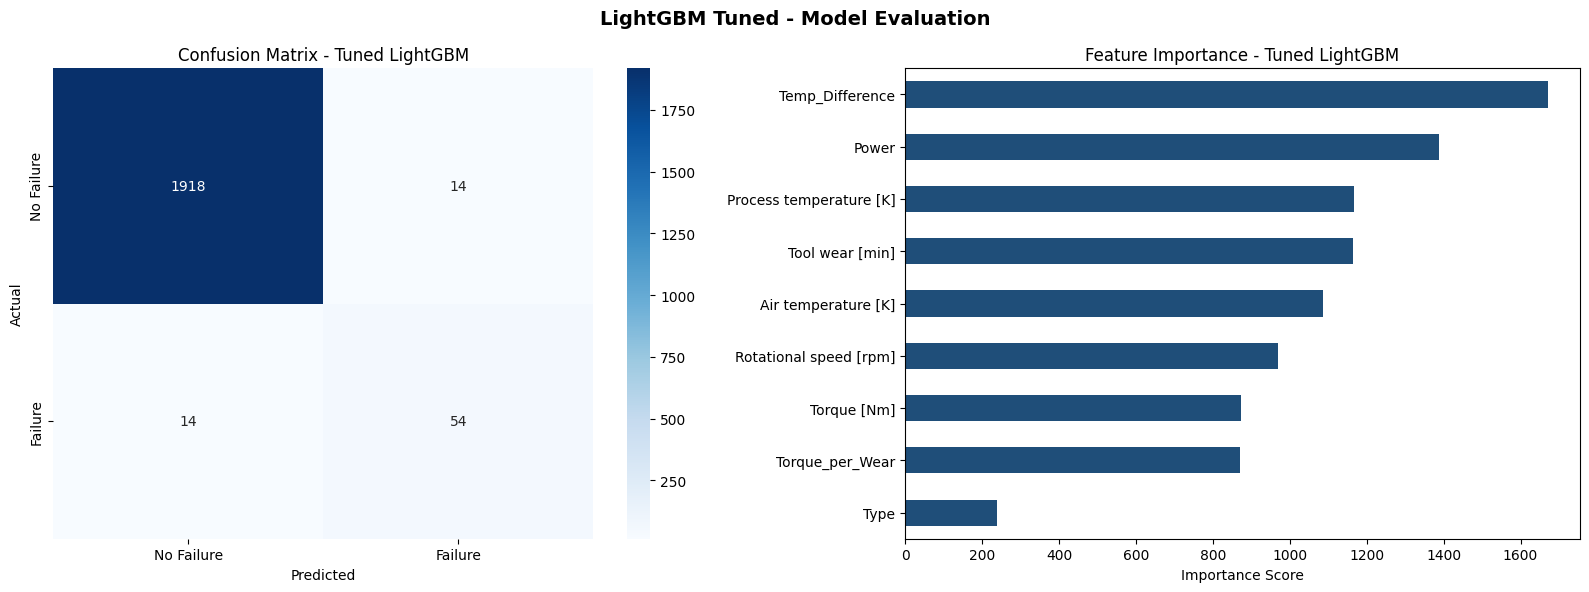

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM Tuned - Model Evaluation', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
axes[0].set_title('Confusion Matrix - Tuned LightGBM')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. Feature Importance
feat_imp = pd.Series(
    search.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', ax=axes[1], color='#1F4E79')
axes[1].set_title('Feature Importance - Tuned LightGBM')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

##Summary

**Confusion Matrix (Tuned LightGBM):**
- True Positives (failures caught): 54/68 = 79.4%
- False Negatives (missed failures): 14
- False Positives (false alarms): 14
- True Negatives: 1918

**Feature Importance Ranking:**
1. Temp_Difference (engineered) ← Most important
2. Power (engineered) ← Second most important
3. Process temperature [K]
4. Tool wear [min]
5. Air temperature [K]
6. Rotational speed [rpm]
7. Torque [Nm]
8. Torque_per_Wear (engineered)
9. Type ← Least important

**Key insight:** Both top engineered features outperformed all raw sensor readings,
validating domain-driven feature engineering over raw measurements.

##**Phase 1B**

##**Preparing Multi-Class Target**

In [13]:
# Create multi-class target from failure type columns
# Only look at rows where a failure actually occurred
failure_df = df[df['Machine failure'] == 1].copy()

# Assign failure type label
def get_failure_type(row):
    if row['TWF'] == 1: return 'TWF'
    if row['HDF'] == 1: return 'HDF'
    if row['PWF'] == 1: return 'PWF'
    if row['OSF'] == 1: return 'OSF'
    if row['RNF'] == 1: return 'RNF'
    return 'Unknown'

failure_df['Failure_Type'] = failure_df.apply(get_failure_type, axis=1)

print("Failure type distribution:")
print(failure_df['Failure_Type'].value_counts())
print("\nTotal failure rows:", len(failure_df))

Failure type distribution:
Failure_Type
HDF        115
PWF         91
OSF         78
TWF         46
Unknown      9
Name: count, dtype: int64

Total failure rows: 339


In [14]:
# Investigate unknown cases
print("=== Unknown failure rows ===")
unknown_rows = failure_df[failure_df['Failure_Type'] == 'Unknown']
print(unknown_rows[['Type', 'Air temperature [K]', 'Process temperature [K]',
                     'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                     'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']].to_string())

# Check for rows with multiple failure flags
print("\n=== Rows with multiple failure types ===")
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
multi_failure = failure_df[failure_df[failure_cols].sum(axis=1) > 1]
print(f"Count: {len(multi_failure)}")
print(multi_failure[failure_cols].value_counts().head(10))

=== Unknown failure rows ===
      Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  OSF  RNF  Machine failure
1437     0                298.8                    309.9                    1439         45.2               40    0    0    0    0    0                1
2749     2                299.7                    309.2                    1685         28.9              179    0    0    0    0    0                1
4044     2                301.9                    310.9                    1419         47.7               20    0    0    0    0    0                1
4684     2                303.6                    311.8                    1421         44.8              101    0    0    0    0    0                1
5536     2                302.3                    311.8                    1363         54.0              119    0    0    0    0    0                1
5941     1                300.6                    31

In [15]:
# Drop unknown failure rows
failure_df = failure_df[failure_df['Failure_Type'] != 'Unknown'].copy()
print("Rows after dropping unknowns:", len(failure_df))
print("\nFinal failure type distribution:")
print(failure_df['Failure_Type'].value_counts())

# Encode failure type
le_failure = LabelEncoder()
failure_df['Failure_Type_Encoded'] = le_failure.fit_transform(failure_df['Failure_Type'])
print("\nEncoding mapping:", dict(zip(le_failure.classes_,
                                      le_failure.transform(le_failure.classes_))))

# Prepare features and target
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'Temp_Difference', 'Power', 'Torque_per_Wear']

X_multi = failure_df[feature_cols]
y_multi = failure_df['Failure_Type_Encoded']

print("\nMulti-class dataset shape:", X_multi.shape)
print("Class distribution:\n", y_multi.value_counts())

Rows after dropping unknowns: 330

Final failure type distribution:
Failure_Type
HDF    115
PWF     91
OSF     78
TWF     46
Name: count, dtype: int64

Encoding mapping: {'HDF': np.int64(0), 'OSF': np.int64(1), 'PWF': np.int64(2), 'TWF': np.int64(3)}

Multi-class dataset shape: (330, 9)
Class distribution:
 Failure_Type_Encoded
0    115
2     91
1     78
3     46
Name: count, dtype: int64


##**Multi-class Model**

In [16]:
# Split — note: small dataset so 80/20 still works
# No SMOTE here — classes are relatively balanced (115/91/78/46)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# Scale
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

print("Train size:", X_train_m.shape)
print("Test size:", X_test_m.shape)
print("\nClass distribution in test set:")
print(y_test_m.value_counts())

# Train LightGBM multi-class
lgbm_multi = LGBMClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.2,
    num_leaves=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)

lgbm_multi.fit(X_train_m_scaled, y_train_m)
y_pred_m = lgbm_multi.predict(X_test_m_scaled)

print("\n=== Multi-Class Classification Report ===")
print(classification_report(y_test_m, y_pred_m,
                            target_names=le_failure.classes_))

Train size: (264, 9)
Test size: (66, 9)

Class distribution in test set:
Failure_Type_Encoded
0    23
2    18
1    16
3     9
Name: count, dtype: int64

=== Multi-Class Classification Report ===
              precision    recall  f1-score   support

         HDF       1.00      1.00      1.00        23
         OSF       0.94      0.94      0.94        16
         PWF       0.95      1.00      0.97        18
         TWF       0.88      0.78      0.82         9

    accuracy                           0.95        66
   macro avg       0.94      0.93      0.93        66
weighted avg       0.95      0.95      0.95        66



##Multi-Class Failure Type Classification

**Approach:** Cascaded classifier — Phase 1b only runs on machines already flagged
as failures by Phase 1a (330 rows, 4 classes)

**No SMOTE needed** — classes relatively balanced (115 HDF / 91 PWF / 78 OSF / 46 TWF)

| Failure Type | Precision | Recall | F1 | Support |
|-------------|-----------|--------|-----|---------|
| HDF | 1.00 | 1.00 | 1.00 | 23 |
| PWF | 0.95 | 1.00 | 0.97 | 18 |
| OSF | 0.94 | 0.94 | 0.94 | 16 |
| TWF | 0.88 | 0.78 | 0.82 | 9 |
| **Overall** | **0.95** | **0.95** | **0.95** | **66** |

- HDF perfectly classified — most common and most learnable
- TWF weakest — only 9 test samples, small support expected to limit performance
- High scores explained by cleaner signal — balanced classes vs severe imbalance in Phase 1a
- Production architecture: All machines → Phase 1a (will it fail?) → Yes → Phase 1b (what type?)